In [1]:
import duckdb
import numpy 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
con = duckdb.connect('../data/workload.duckdb')
videos = con.execute("""
    SELECT
        *
    FROM dim_videos_ml
""").df()
con.close()


In [29]:
pd.set_option('display.max_rows', 500)

In [7]:
videos.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   video_id                        126 non-null    str           
 1   media_title                     126 non-null    str           
 2   video_type                      126 non-null    str           
 3   video_subtype                   126 non-null    str           
 4   media_type                      126 non-null    str           
 5   media_series                    126 non-null    str           
 6   total_hours                     126 non-null    float64       
 7   date_first                      126 non-null    datetime64[us]
 8   date_last                       126 non-null    datetime64[us]
 9   total_day_span                  126 non-null    int64         
 10  active_days_worked              126 non-null    int64         
 11  hours_editing    

In [ ]:
# hours_creation and creation_day_span are now computed in dim_videos (dbt).
# No manual derivation needed here.

In [9]:
videos['hours_creation']

0      23.08
1       7.50
2       7.30
3      18.27
4       4.72
       ...  
121     2.08
122     0.08
123     0.22
124     1.01
125     1.67
Name: hours_creation, Length: 126, dtype: float64

In [ ]:

# Filter to complete videos using the is_complete flag from the seed.
# is_complete=1 is manually maintained in transform/seed/video_labels.csv.
# This replaces the previous hardcoded (title, type, subtype) exclusion list.

videos_complete = videos[videos['is_complete'] == 1].reset_index(drop=True)
print(f"Original: {len(videos)} | Complete (is_complete=1): {len(videos_complete)} | Excluded: {len(videos) - len(videos_complete)}")


In [12]:
videos_complete['hours_creation'].describe()

count    99.000000
mean     17.046566
std       8.775578
min       4.720000
25%       9.610000
50%      15.780000
75%      23.230000
max      53.150000
Name: hours_creation, dtype: float64

<Axes: xlabel='hours_creation', ylabel='Count'>

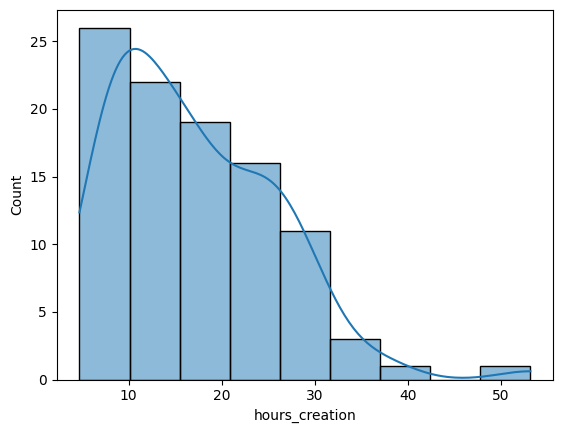

In [13]:
sns.histplot(videos_complete['hours_creation'], kde=True)

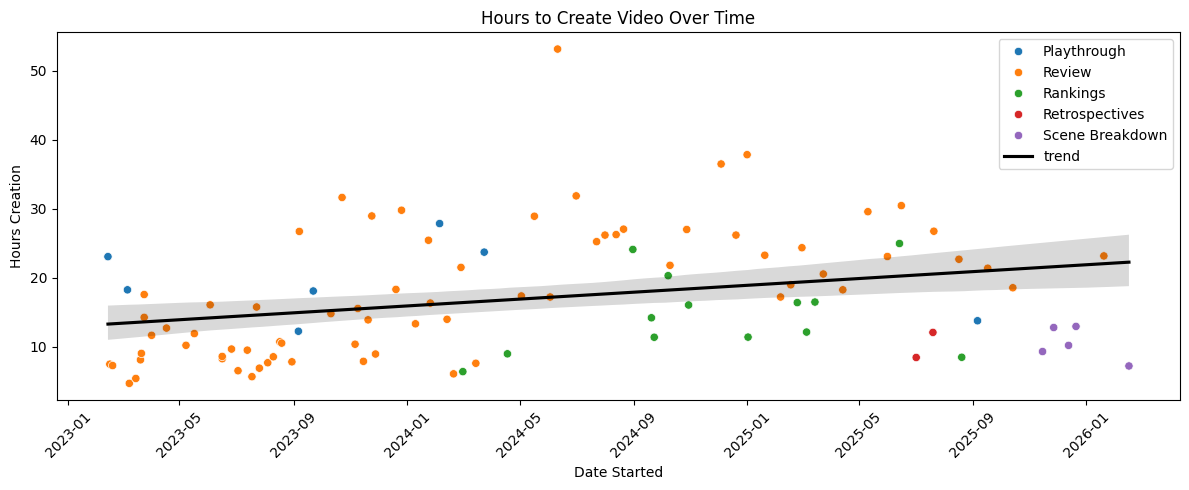

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

videos_plot = videos_complete.sort_values('date_first')

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=videos_plot, x='date_first', y='hours_creation', hue='video_type', ax=ax)
sns.regplot(
    x=mdates.date2num(videos_plot['date_first']),
    y=videos_plot['hours_creation'],
    scatter=False, ax=ax, color='black', label='trend'
)

ax.set_title('Hours to Create Video Over Time')
ax.set_xlabel('Date Started')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


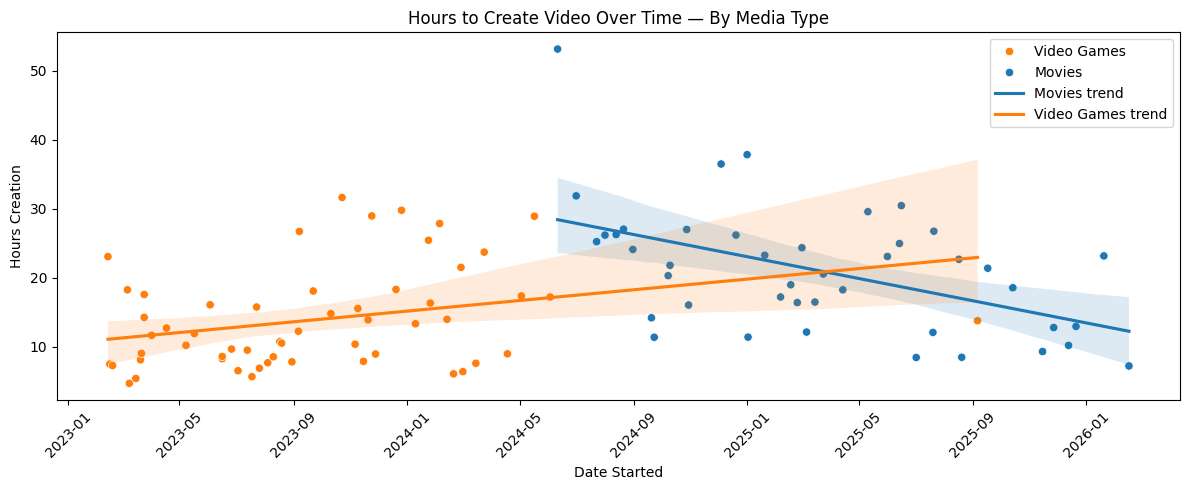

In [28]:
palette = {'Movies': '#1f77b4', 'Video Games': '#ff7f0e'}  # match seaborn defaults

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=videos_plot, x='date_first', y='hours_creation', 
                hue='media_type', palette=palette, ax=ax)

for media, group in videos_plot.groupby('media_type'):
    sns.regplot(
        x=mdates.date2num(group['date_first']),
        y=group['hours_creation'],
        scatter=False, ax=ax, color=palette[media], label=f'{media} trend'
    )

ax.set_title('Hours to Create Video Over Time — By Media Type')
ax.set_xlabel('Date Started')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



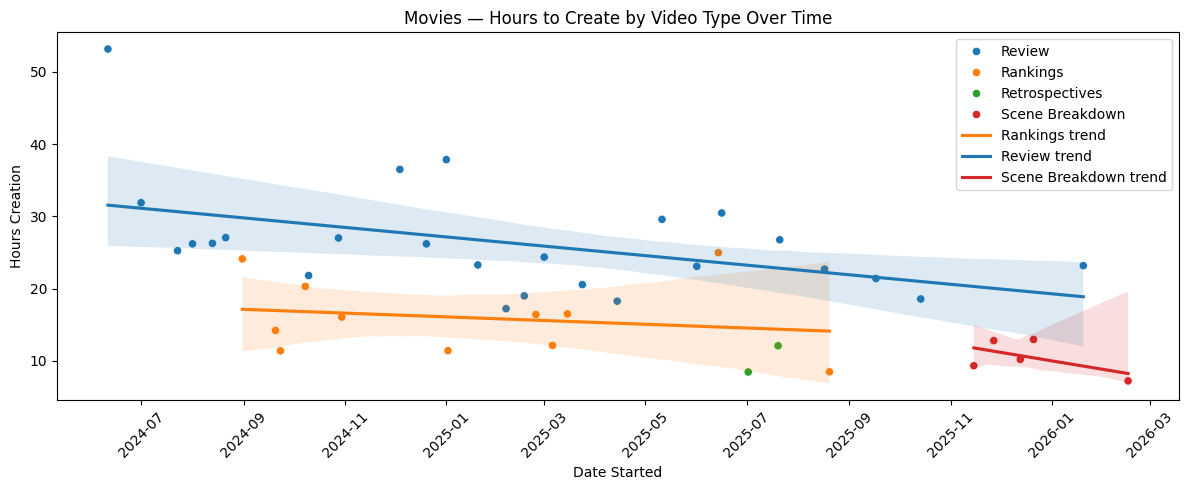

In [15]:
movie_videos = videos_plot[videos_plot['media_type'] == 'Movies']

palette_vtype = {t: c for t, c in zip(
    movie_videos['video_type'].unique(), 
    sns.color_palette(n_colors=movie_videos['video_type'].nunique())
)}

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=movie_videos, x='date_first', y='hours_creation',
                hue='video_type', palette=palette_vtype, ax=ax)

for vtype, group in movie_videos.groupby('video_type'):
    if len(group) >= 5:  # only draw trend if enough points
        sns.regplot(
            x=mdates.date2num(group['date_first']),
            y=group['hours_creation'],
            scatter=False, ax=ax, color=palette_vtype[vtype], label=f'{vtype} trend'
        )

ax.set_title('Movies — Hours to Create by Video Type Over Time')
ax.set_xlabel('Date Started')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Next Step...relabel Jurassic World Short Review as a "Retrospective"
#Then in the Seed file, add in a new column:  "Unscripted" or "Not"

In [17]:
videos_complete['complexity_new'].value_counts(dropna=False)

complexity_new
0       68
1       30
<NA>     1
Name: count, dtype: Int64

In [18]:
videos_complete['complexity_media_depth'].value_counts(dropna=False)

complexity_media_depth
1       82
0       16
<NA>     1
Name: count, dtype: Int64

In [19]:
videos_complete['complexity_delivery_style'].value_counts(dropna=False)

complexity_delivery_style
1       81
0       17
<NA>     1
Name: count, dtype: Int64

In [20]:
videos_complete['complexity_logistics'].value_counts(dropna=False)

complexity_logistics
0       89
1        9
<NA>     1
Name: count, dtype: Int64

In [5]:
videos_complete['complexity_worklife'].value_counts(dropna=False)

complexity_worklife
0    80
1    19
Name: count, dtype: Int64

In [ ]:

# --- hours_creation by video_type ---
# Horizontal box + strip, sorted by median. n= embedded in y-tick labels.

order_vtype = (
    videos_complete
    .groupby('video_type')['hours_creation']
    .median()
    .sort_values()
    .index.tolist()
)
counts_vtype = videos_complete['video_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=videos_complete, y='video_type', x='hours_creation',
    order=order_vtype, ax=ax, color='lightsteelblue', width=0.5, fliersize=0
)
sns.stripplot(
    data=videos_complete, y='video_type', x='hours_creation',
    order=order_vtype, ax=ax, color='steelblue', alpha=0.6, jitter=True, size=5
)
ax.set_yticklabels([f'{v}  (n={counts_vtype.get(v, 0)})' for v in order_vtype])
ax.set_title('hours_creation by video_type (sorted by median)')
ax.set_xlabel('Hours Creation')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [ ]:

# --- hours_creation by Complexity Flags ---
# 2x3 grid, one subplot per flag. Box + strip overlay, n= annotated above each box.
# sharey=True so all panels are on the same scale for direct comparison.
# Note: 1 video has no label data and is dropped per flag via dropna().

complexity_cols = [
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
    'complexity_logistics',
    'complexity_worklife',
]

ymax = videos_complete['hours_creation'].max()
y_top = ymax * 1.12  # headroom for n= labels

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharey=True)
axes_flat = axes.flatten()

for i, col in enumerate(complexity_cols):
    ax = axes_flat[i]
    df_flag = (
        videos_complete[['hours_creation', col]]
        .dropna()
        .copy()
    )
    df_flag[col] = df_flag[col].astype(int)
    counts_flag = df_flag[col].value_counts().sort_index()

    sns.boxplot(
        data=df_flag, x=col, y='hours_creation', order=[0, 1],
        ax=ax, color='lightsteelblue', width=0.5, fliersize=0
    )
    sns.stripplot(
        data=df_flag, x=col, y='hours_creation', order=[0, 1],
        ax=ax, color='steelblue', alpha=0.6, jitter=True, size=5
    )
    # Annotate n= above each box
    for j, val in enumerate([0, 1]):
        n = counts_flag.get(val, 0)
        ax.text(j, ymax + ymax * 0.03, f'n={n}', ha='center', va='bottom', fontsize=9)

    ax.set_ylim(top=y_top)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_xticklabels(['0 (No)', '1 (Yes)'])
    ax.set_ylabel('Hours Creation' if i % 3 == 0 else '')

axes_flat[-1].set_visible(False)
fig.suptitle('hours_creation by Complexity Flags', fontsize=13)
plt.tight_layout()
plt.show()


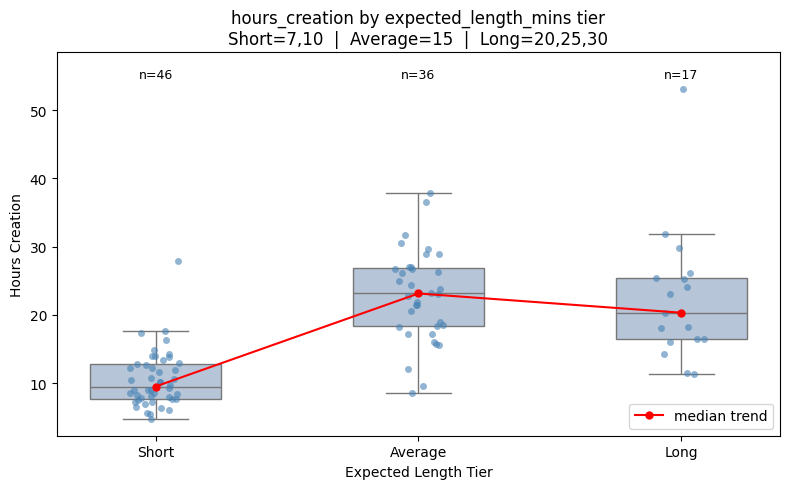

In [25]:

# --- hours_creation vs expected_length_mins ---
# Grouped into 3 tiers: Short (7,10), Average (15), Long (20,25,30)
# Sample sizes: Short ~46, Average ~36, Long ~17

import sys; sys.path.append('..')
from src.constants import LENGTH_TIER_MAP, LENGTH_TIER_ORDER

df_len = (
    videos_complete[['expected_length_mins', 'hours_creation']]
    .dropna()
    .copy()
)
df_len['expected_length_mins'] = df_len['expected_length_mins'].astype(int)
df_len['length_tier'] = df_len['expected_length_mins'].map(LENGTH_TIER_MAP)

counts_tier = df_len['length_tier'].value_counts()
ymax_len = df_len['hours_creation'].max()

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_len, x='length_tier', y='hours_creation', order=LENGTH_TIER_ORDER,
    ax=ax, color='lightsteelblue', width=0.5, fliersize=0
)
sns.stripplot(
    data=df_len, x='length_tier', y='hours_creation', order=LENGTH_TIER_ORDER,
    ax=ax, color='steelblue', alpha=0.6, jitter=True, size=5
)

# Median trend line
medians = [df_len[df_len['length_tier'] == t]['hours_creation'].median() for t in LENGTH_TIER_ORDER]
ax.plot(range(len(LENGTH_TIER_ORDER)), medians, color='red', marker='o',
        linewidth=1.5, markersize=5, label='median trend', zorder=5)

# n= annotations
for j, t in enumerate(LENGTH_TIER_ORDER):
    n = counts_tier.get(t, 0)
    ax.text(j, ymax_len + ymax_len * 0.02, f'n={n}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(top=ymax_len * 1.1)
ax.set_title('hours_creation by expected_length_mins tier\nShort=7,10  |  Average=15  |  Long=20,25,30')
ax.set_xlabel('Expected Length Tier')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.tight_layout()
plt.show()


In [30]:
for col in complexity_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(videos_complete['video_type'], 
                      videos_complete[col].astype('Int64'), 
                      margins=True))



--- complexity_new ---
complexity_new    0   1  All
video_type                  
Playthrough       3   4    7
Quick Thoughts    0   2    2
Rankings          9   4   13
Review           52  20   72
Scene Breakdown   4   1    5
All              68  31   99

--- complexity_media_depth ---
complexity_media_depth   0   1  All
video_type                         
Playthrough              3   4    7
Quick Thoughts           1   1    2
Rankings                 0  13   13
Review                   8  64   72
Scene Breakdown          5   0    5
All                     17  82   99

--- complexity_delivery_style ---
complexity_delivery_style   0   1  All
video_type                            
Playthrough                 0   7    7
Quick Thoughts              2   0    2
Rankings                   10   3   13
Review                      1  71   72
Scene Breakdown             5   0    5
All                        18  81   99

--- complexity_logistics ---
complexity_logistics   0  1  All
video_type    

In [ ]:
#based on above, complexity_new is not a proxy for video_type, but compleity_media depth is, as is delivery style, logistics and worklife are more
#temporal features.

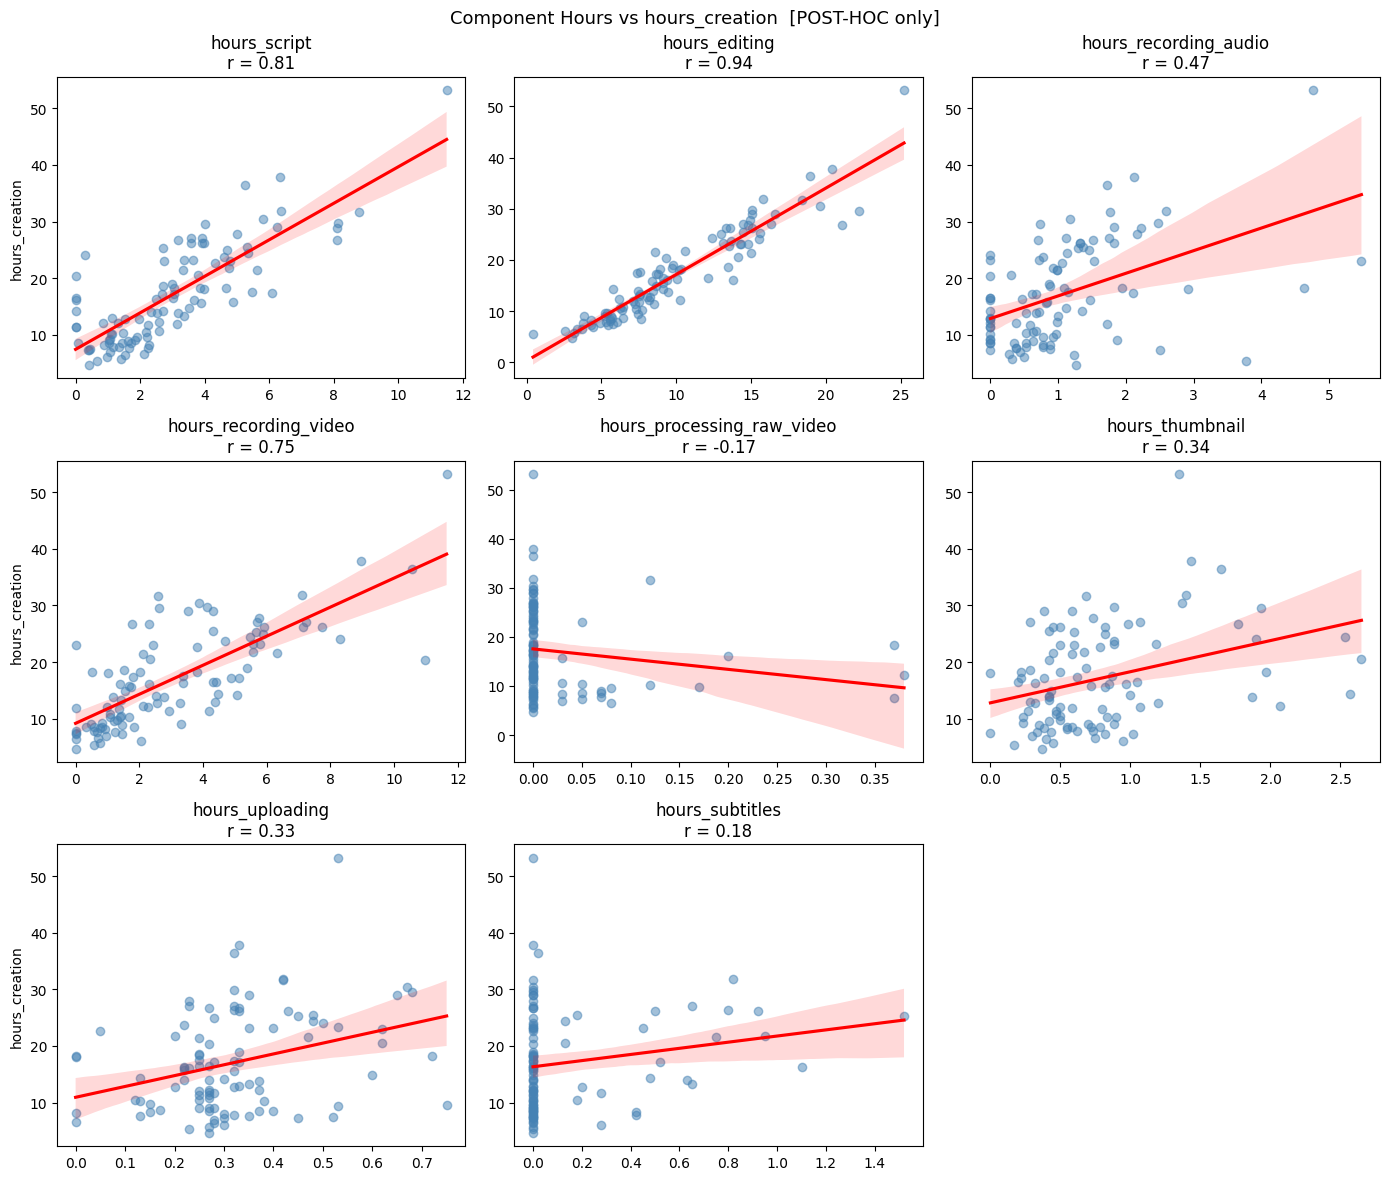

In [26]:

# ============================================================
# POST-HOC SCATTER ANALYSIS — for variance decomposition only.
# These columns are computed AFTER a video is finished.
# None of them can be used as features in the predictive model.
# ============================================================

# --- Component hours vs hours_creation ---
# Pearson r shown in each title to rank which components drive total hours.
# Note: hours_pre_processing + hours_processing = hours_creation by definition,
# so those are excluded here — their r would be trivially high.

from scipy import stats

component_cols = [
    'hours_script',
    'hours_editing',
    'hours_recording_audio',
    'hours_recording_video',
    'hours_processing_raw_video',
    'hours_thumbnail',
    'hours_uploading',
    'hours_subtitles',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes_flat = axes.flatten()

for i, col in enumerate(component_cols):
    ax = axes_flat[i]
    df_plot = videos_complete[['hours_creation', col]].dropna()
    r, _ = stats.pearsonr(df_plot[col], df_plot['hours_creation'])

    sns.regplot(
        data=df_plot, x=col, y='hours_creation', ax=ax,
        scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
        line_kws={'color': 'red'}
    )
    ax.set_title(f'{col}\nr = {r:.2f}')
    ax.set_xlabel('')
    ax.set_ylabel('hours_creation' if i % 3 == 0 else '')

axes_flat[-1].set_visible(False)
fig.suptitle('Component Hours vs hours_creation  [POST-HOC only]', fontsize=13)
plt.tight_layout()
plt.show()


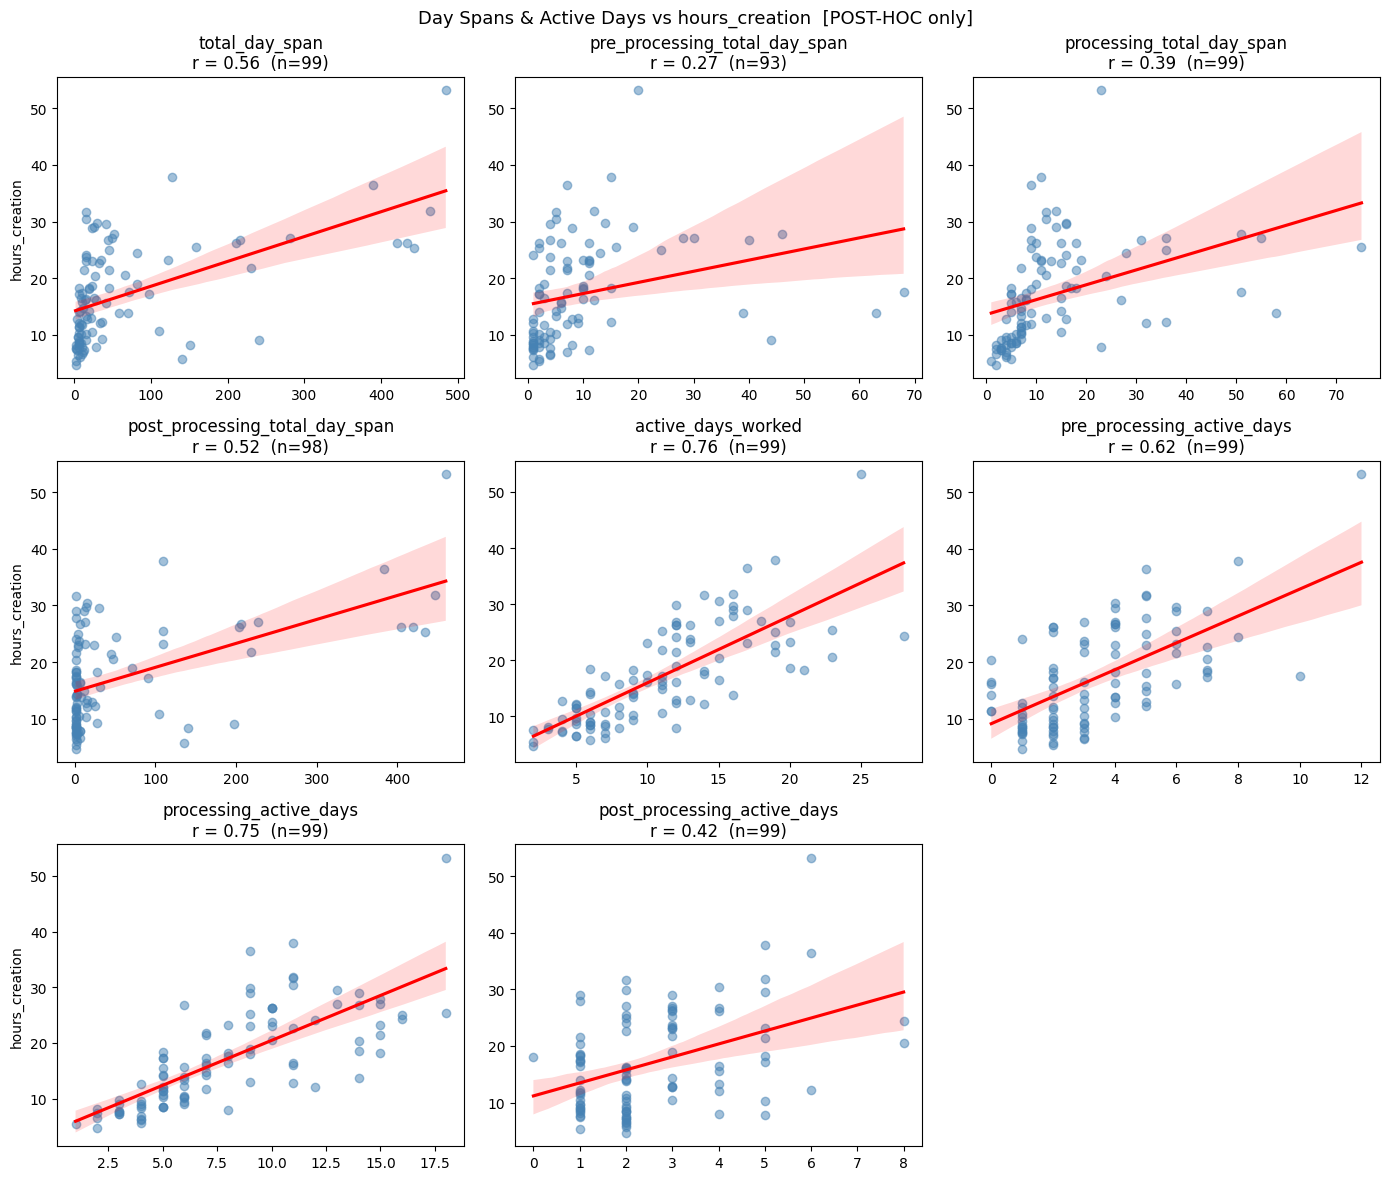

In [27]:

# --- Day spans and active days vs hours_creation  [POST-HOC only] ---
# Day spans measure calendar time elapsed; active days measure unique days worked.
# These inform the secondary target (total_day_span) as much as hours_creation.
# Some have NaNs for videos where that phase didn't occur — dropped per subplot.

span_cols = [
    'total_day_span',
    'pre_processing_total_day_span',
    'processing_total_day_span',
    'post_processing_total_day_span',
    'active_days_worked',
    'pre_processing_active_days',
    'processing_active_days',
    'post_processing_active_days',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes_flat = axes.flatten()

for i, col in enumerate(span_cols):
    ax = axes_flat[i]
    df_plot = (
        videos_complete[['hours_creation', col]]
        .dropna()
        .astype({'hours_creation': float, col: float})
    )
    r, _ = stats.pearsonr(df_plot[col], df_plot['hours_creation'])

    sns.regplot(
        data=df_plot, x=col, y='hours_creation', ax=ax,
        scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
        line_kws={'color': 'red'}
    )
    ax.set_title(f'{col}\nr = {r:.2f}  (n={len(df_plot)})')
    ax.set_xlabel('')
    ax.set_ylabel('hours_creation' if i % 3 == 0 else '')

axes_flat[-1].set_visible(False)
fig.suptitle('Day Spans & Active Days vs hours_creation  [POST-HOC only]', fontsize=13)
plt.tight_layout()
plt.show()


## Outlier Investigation — max hours_creation (53.15 hrs)

In [ ]:

# --- Identify the outlier ---
outlier_thresh = 45  # clear gap between next-highest and max
outlier_mask = videos_complete['hours_creation'] >= outlier_thresh

print(f"Videos with hours_creation >= {outlier_thresh}:")
print(videos_complete[outlier_mask][[
    'media_title', 'video_type', 'video_subtype', 'media_type',
    'expected_length_mins', 'hours_creation',
    'hours_pre_processing', 'hours_processing',
    'hours_script', 'hours_editing', 'hours_recording_audio', 'hours_recording_video',
    'hours_processing_raw_video',
    'total_day_span', 'active_days_worked',
    'complexity_new', 'complexity_media_depth', 'complexity_delivery_style',
    'complexity_logistics', 'complexity_worklife',
    'date_first', 'date_last',
]].T.to_string())

print(f"\n--- Top 5 by hours_creation for context ---")
print(videos_complete.nlargest(5, 'hours_creation')[[
    'media_title', 'video_type', 'video_subtype', 'expected_length_mins', 'hours_creation',
]].to_string())


In [ ]:

# --- Outlier visual: hours_creation distribution with outlier flagged ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram — outlier visible at far right
axes[0].axvline(videos_complete['hours_creation'].max(), color='red', linestyle='--', label='outlier')
sns.histplot(videos_complete['hours_creation'], kde=True, ax=axes[0])
axes[0].set_title('hours_creation — full distribution')
axes[0].set_xlabel('Hours Creation')
axes[0].legend()

# Right: without outlier — what the rest looks like
no_outlier = videos_complete[~outlier_mask]['hours_creation']
sns.histplot(no_outlier, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title(f'hours_creation — outlier removed (n={len(no_outlier)})')
axes[1].set_xlabel('Hours Creation')

plt.tight_layout()
plt.show()

print(f"\nWith outlier:    mean={videos_complete['hours_creation'].mean():.2f}  median={videos_complete['hours_creation'].median():.2f}  std={videos_complete['hours_creation'].std():.2f}")
print(f"Without outlier: mean={no_outlier.mean():.2f}  median={no_outlier.median():.2f}  std={no_outlier.std():.2f}")


In [ ]:

# --- Outlier handling decision ---
# Options:
#   'keep'   — leave as-is; model must absorb the variance
#   'remove' — drop from training; note it still represents a real video type
#   'cap'    — winsorize at the 95th or 99th percentile
#
# Decision: UPDATE THIS AFTER INVESTIGATION ABOVE
OUTLIER_HANDLING = 'keep'  # <-- set to 'keep', 'remove', or 'cap'
CAP_PERCENTILE = 0.99       # only used if OUTLIER_HANDLING == 'cap'

if OUTLIER_HANDLING == 'remove':
    videos_model = videos_complete[~outlier_mask].reset_index(drop=True)
    print(f"Outlier removed. Modeling set: {len(videos_model)} videos")
elif OUTLIER_HANDLING == 'cap':
    cap_val = videos_complete['hours_creation'].quantile(CAP_PERCENTILE)
    videos_model = videos_complete.copy()
    videos_model['hours_creation'] = videos_model['hours_creation'].clip(upper=cap_val)
    print(f"Capped at {CAP_PERCENTILE:.0%} percentile ({cap_val:.2f} hrs). Modeling set: {len(videos_model)} videos")
else:
    videos_model = videos_complete.copy()
    print(f"Keeping outlier. Modeling set: {len(videos_model)} videos")

print(f"hours_creation: mean={videos_model['hours_creation'].mean():.2f}  median={videos_model['hours_creation'].median():.2f}  std={videos_model['hours_creation'].std():.2f}")


In [ ]:

# --- Q-Q plots: raw vs log-transformed hours_creation ---
# Left:  raw hours_creation vs normal quantiles.
#        If the target were normally distributed, points would fall on the line.
#        Heavy deviation (especially at the upper tail) motivates the transform.
#
# Right: log(hours_creation) vs normal quantiles.
#        This is the distributional assumption we're actually making when we
#        fit a linear model in log-space and apply the smearing correction
#        exp(predicted_log + σ²/2). If points track the line, the assumption holds.
#        One point above the line at the upper tail is acceptable — that's Halloween.

from scipy import stats
import numpy as np

y_raw = videos_model['hours_creation'].dropna()
y_log = np.log(y_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Raw ---
(osm_raw, osr_raw), (slope_raw, intercept_raw, r_raw) = stats.probplot(y_raw, dist='norm')
axes[0].scatter(osm_raw, osr_raw, color='steelblue', alpha=0.7, s=30)
axes[0].plot(osm_raw, slope_raw * np.array(osm_raw) + intercept_raw, color='red', linewidth=1.5)
axes[0].set_title(f'Q-Q: hours_creation (raw)\nR² = {r_raw**2:.3f}')
axes[0].set_xlabel('Theoretical quantiles (Normal)')
axes[0].set_ylabel('Sample quantiles')

# --- Log-transformed ---
(osm_log, osr_log), (slope_log, intercept_log, r_log) = stats.probplot(y_log, dist='norm')
axes[1].scatter(osm_log, osr_log, color='steelblue', alpha=0.7, s=30)
axes[1].plot(osm_log, slope_log * np.array(osm_log) + intercept_log, color='red', linewidth=1.5)
axes[1].set_title(f'Q-Q: log(hours_creation)\nR² = {r_log**2:.3f}')
axes[1].set_xlabel('Theoretical quantiles (Normal)')
axes[1].set_ylabel('Sample quantiles (log scale)')

fig.suptitle('Normality check — raw vs log-transformed target', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw   hours_creation — Shapiro-Wilk: W={stats.shapiro(y_raw).statistic:.4f}, p={stats.shapiro(y_raw).pvalue:.4f}")
print(f"Log   hours_creation — Shapiro-Wilk: W={stats.shapiro(y_log).statistic:.4f}, p={stats.shapiro(y_log).pvalue:.4f}")
print(f"\nInterpretation:")
print(f"  p > 0.05 → cannot reject normality (assumption is defensible)")
print(f"  p < 0.05 → evidence against normality (transform may not fully fix the issue)")


## Correlation Matrix — Proposed Model Features vs hours_creation

Spearman rank correlation is used throughout because:
- Binary flags (0/1) violate Pearson's normality assumption
- `expected_length_mins` is ordinal (tier-encoded), not continuous
- `hours_creation` is right-skewed (outlier present)

`media_type` is binary-encoded: Movies=1, Video Games=0.
`expected_length_mins` uses the raw tier integer (7→Short, 15→Average, 20+→Long) —
Spearman handles the ordinal spacing without needing explicit category encoding.

In [ ]:

# --- Build feature matrix from videos_model (post-outlier-handling) ---
# Drops the 1 video with no label data (no expected_length_mins / complexity flags).

df_corr = videos_model.copy()

# Encode media_type: Movies=1, Video Games=0
df_corr['media_type_enc'] = (df_corr['media_type'] == 'Movies').astype(int)

# Encode video_type as dummies — kept separate from model features for exploratory analysis.
# Note: Quick Thoughts n=2 is too sparse for reliable Spearman correlation.
vtype_dummies = pd.get_dummies(df_corr['video_type'], prefix='vtype').astype(int)
df_corr = pd.concat([df_corr, vtype_dummies], axis=1)

feature_cols = [
    'expected_length_mins',
    'media_type_enc',
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
    'complexity_logistics',
    'complexity_worklife',
]

vtype_cols = sorted(vtype_dummies.columns.tolist())

df_corr_clean = (
    df_corr[feature_cols + vtype_cols + ['hours_creation']]
    .dropna()
    .astype(float)
)

print(f"Correlation matrix built on {len(df_corr_clean)} videos ({len(videos_model) - len(df_corr_clean)} dropped for missing labels)")
print(f"\nvideo_type dummy counts:")
for col in vtype_cols:
    print(f"  {col}: n={int(df_corr_clean[col].sum())}  {'(sparse — treat with caution)' if df_corr_clean[col].sum() < 5 else ''}")


In [ ]:

# --- Spearman correlation matrix heatmap ---
# Includes model features, video_type dummies (exploratory), and target.
# video_type dummies are shaded differently in the label to distinguish them
# from actual model features.

col_labels = {
    'expected_length_mins':        'expected_length_mins',
    'media_type_enc':              'media_type (Movies=1)',
    'complexity_new':              'complexity_new',
    'complexity_media_depth':      'complexity_media_depth',
    'complexity_delivery_style':   'complexity_delivery_style',
    'complexity_logistics':        'complexity_logistics',
    'complexity_worklife':         'complexity_worklife',
    'vtype_Playthrough':           '[vtype] Playthrough',
    'vtype_Quick Thoughts':        '[vtype] Quick Thoughts',
    'vtype_Rankings':              '[vtype] Rankings',
    'vtype_Review':                '[vtype] Review',
    'vtype_Scene Breakdown':       '[vtype] Scene Breakdown',
    'hours_creation':              'hours_creation [TARGET]',
}

all_cols = feature_cols + vtype_cols + ['hours_creation']
corr_df = df_corr_clean[all_cols].rename(columns=col_labels)
spearman_corr = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    spearman_corr,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5,
    ax=ax
)
ax.set_title('Spearman Correlation — Model Features + video_type dummies + Target\n[vtype] columns are exploratory only', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:

# --- Feature-to-target correlations ranked ---
# Model features and video_type dummies ranked separately so the comparison is clear.

target_col = 'hours_creation [TARGET]'
target_corr_all = (
    spearman_corr[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)

# Split into model features vs video_type exploratory
vtype_label_prefix = '[vtype]'
is_vtype = target_corr_all.index.str.startswith(vtype_label_prefix)
target_corr_features = target_corr_all[~is_vtype]
target_corr_vtype    = target_corr_all[is_vtype]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr_series, title in [
    (axes[0], target_corr_features, 'Model Features'),
    (axes[1], target_corr_vtype,    'video_type dummies (exploratory)'),
]:
    colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_series.values[::-1]]
    bars = ax.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(f'Spearman r with hours_creation\n{title}', fontsize=11)
    ax.set_xlabel('Spearman r')
    for bar, val in zip(bars, corr_series.values[::-1]):
        ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nModel features — Spearman r with hours_creation (ranked):")
print(target_corr_features.to_string())
print("\nvideo_type dummies — Spearman r with hours_creation (ranked):")
print(target_corr_vtype.to_string())


## Walk-Forward Split — Parameter Decisions

### Date anchor: `date_first` (when work began), not completion date

The model predicts **before** you start a video — at that point you know `expected_length_mins` and the complexity flags. The walk-forward ordering should therefore be by `date_first` (when the first session occurred).

Using completion date would be wrong: if video B starts before video A finishes, completion-date ordering would place B after A in training when you actually had A's features visible during B's production. `date_first` preserves the causal order of decisions.

### Rolling average to check for content-shift effect

A 10-video rolling mean of `hours_creation` (sorted by `date_first`) shows whether the June 2024 movie switch caused a structural level shift. If movies land at a clearly different mean, it suggests media_type drift that walk-forward CV will naturally capture.

In [ ]:

# --- Rolling average of hours_creation over time ---
# Sort complete videos by date_first (when work began on each video).
# 10-video rolling window — enough to smooth noise but short enough to reveal trends.
# Vertical line at 2024-06-11: first session of Halloween Review (content shift to Movies).

import numpy as np

CONTENT_SHIFT_DATE = pd.Timestamp('2024-06-11')
ROLLING_WINDOW = 10

df_roll = (
    videos_complete[['date_first', 'hours_creation', 'media_type', 'video_type', 'media_title']]
    .dropna()
    .sort_values('date_first')
    .reset_index(drop=True)
)
df_roll['rolling_mean'] = df_roll['hours_creation'].rolling(ROLLING_WINDOW, min_periods=5).mean()
df_roll['video_index'] = df_roll.index + 1  # 1-based rank by date_first

palette_mt = {'Movies': '#d73027', 'Video Games': '#4575b4'}

fig, ax = plt.subplots(figsize=(14, 5))

for mtype, grp in df_roll.groupby('media_type'):
    ax.scatter(
        grp['video_index'], grp['hours_creation'],
        label=mtype, color=palette_mt.get(mtype, 'gray'),
        alpha=0.65, s=35, zorder=3
    )

ax.plot(df_roll['video_index'], df_roll['rolling_mean'],
        color='black', linewidth=2, label=f'{ROLLING_WINDOW}-video rolling mean', zorder=4)

# Content shift line
shift_idx = df_roll[df_roll['date_first'] >= CONTENT_SHIFT_DATE]['video_index'].iloc[0]
ax.axvline(shift_idx, color='orange', linestyle='--', linewidth=1.5, label=f'Content shift (video #{shift_idx}, {CONTENT_SHIFT_DATE.date()})')

# Mean reference lines per media type
for mtype, grp in df_roll.groupby('media_type'):
    mean_val = grp['hours_creation'].mean()
    color = palette_mt.get(mtype, 'gray')
    ax.axhline(mean_val, color=color, linestyle=':', linewidth=1, alpha=0.7)
    ax.text(df_roll['video_index'].max() + 0.5, mean_val, f'{mtype} mean\n{mean_val:.1f}h',
            color=color, va='center', fontsize=8)

ax.set_xlabel('Video # (sorted by date_first)')
ax.set_ylabel('hours_creation')
ax.set_title(f'hours_creation Over Time — {ROLLING_WINDOW}-video rolling mean\nOrdered by date_first; vertical line = content shift to Movies')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Summary stats by media type
print("hours_creation by media_type:")
print(df_roll.groupby('media_type')['hours_creation'].agg(['count', 'mean', 'median', 'std']).round(2))


In [ ]:

# --- Walk-forward split parameters ---
# Test set: 25 most recent videos by date_first.
# Train set: everything before the cutoff.
# Cutoff = date_first of the 25th-most-recent video (the earliest video in the test set).

N_TEST = 25

df_split = (
    videos_complete[['date_first', 'hours_creation', 'media_title', 'video_type', 'media_type']]
    .dropna(subset=['hours_creation'])
    .sort_values('date_first')
    .reset_index(drop=True)
)

n_total = len(df_split)
cutoff_idx = n_total - N_TEST  # first index in test set
cutoff_date = df_split.loc[cutoff_idx, 'date_first']

train_df = df_split.iloc[:cutoff_idx].copy()
test_df  = df_split.iloc[cutoff_idx:].copy()

print("=" * 55)
print(f"Walk-forward split parameters")
print("=" * 55)
print(f"Total complete videos (is_complete=1): {n_total}")
print(f"Train set: {len(train_df)}  ({train_df['date_first'].min().date()} → {train_df['date_first'].max().date()})")
print(f"Test set:  {len(test_df)}   ({test_df['date_first'].min().date()} → {test_df['date_first'].max().date()})")
print(f"Cutoff date (first test video): {cutoff_date.date()}")
print()

# Media type breakdown in each split
print("Media type breakdown:")
for label, df in [('Train', train_df), ('Test', test_df)]:
    vc = df['media_type'].value_counts()
    print(f"  {label}: {dict(vc)}")

print()
print(f"First 5 test videos (earliest in test set):")
print(test_df.head(5)[['date_first', 'media_title', 'video_type', 'media_type', 'hours_creation']].to_string(index=False))
print()
print(f"Last 5 train videos (latest in train set):")
print(train_df.tail(5)[['date_first', 'media_title', 'video_type', 'media_type', 'hours_creation']].to_string(index=False))

# Visual split timeline
fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(train_df['date_first'], train_df['hours_creation'],
           color='#4575b4', alpha=0.65, s=35, label=f'Train (n={len(train_df)})')
ax.scatter(test_df['date_first'], test_df['hours_creation'],
           color='#d73027', alpha=0.65, s=35, label=f'Test (n={len(test_df)})')
ax.axvline(cutoff_date, color='black', linestyle='--', linewidth=1.5,
           label=f'Cutoff: {cutoff_date.date()}')
ax.set_xlabel('date_first')
ax.set_ylabel('hours_creation')
ax.set_title('Walk-Forward Train / Test Split')
ax.legend()
plt.tight_layout()
plt.show()
